# 1 — Install

In [3]:
import subprocess, sys, os

FLAG = '/tmp/fre_installed.flag'
if not os.path.exists(FLAG):
    pkgs = [
        'numpy==1.24.4',
        'facenet-pytorch==2.5.3',
        'onnx>=1.14.0',
        'onnxruntime>=1.15.0',
        'seaborn>=0.12.0',
        'pyyaml>=6.0',
        'tensorboard>=2.13.0',
    ]
    for p in pkgs:
        print(f'Installing {p}...', end=' ', flush=True)
        r = subprocess.run([sys.executable,'-m','pip','install','-q',p],
                           capture_output=True, text=True)
        print('OK' if r.returncode==0 else f'GAGAL: {r.stderr[-100:]}')
    open(FLAG, 'w').close()
    print('\n== INSTALL SELESAI ==')
    print('Klik: Runtime -> Restart Runtime')
    print('Lalu jalankan mulai dari cell berikutnya')
else:
    print('Packages sudah terinstall.')

Packages sudah terinstall.


# 2 — Setup

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BASE_DIR = '/content/drive/MyDrive/Projek/face_recognition_ewallet'

In [6]:
import sys, os
sys.path.insert(0, BASE_DIR)
os.chdir(BASE_DIR)

from src.utils import load_config, resolve_paths, set_seed, setup_logging, get_device

cfg    = load_config('config/config.yaml')
cfg    = resolve_paths(cfg, BASE_DIR)
set_seed(cfg['project']['seed'])
device = get_device()
setup_logging(cfg['paths']['logs'], 'training')
print(f"Setup selesai | device={device}")

🚀 GPU: Tesla T4  |  VRAM: 15.6 GB
Setup selesai | device=cuda


# 3 — Cek GPU

In [7]:
import torch

if torch.cuda.is_available():
    g    = torch.cuda.get_device_properties(0)
    vram = g.total_memory / 1e9
    print(f"GPU   : {g.name}")
    print(f"VRAM  : {vram:.1f} GB")
    print(f"CUDA  : {torch.version.cuda}")
    if vram < 8:
        print("VRAM < 8GB -> pertimbangkan kurangi batch_size di config.yaml")
else:
    print("GPU tidak terdeteksi.")
    print("Aktifkan: Runtime -> Change runtime type -> GPU -> T4 GPU")

GPU   : Tesla T4
VRAM  : 15.6 GB
CUDA  : 12.8


# 4 — Load Dataset & Split

In [8]:
from src.data.dataset_loader import DatasetLoader

loader        = DatasetLoader(cfg)
paths, labels = loader.scan(cfg['data']['processed_dir'])
train_d, val_d, test_d = loader.split(paths, labels)
num_classes = len(loader.class_to_idx)

Xtr, ytr   = train_d
Xval, yval = val_d
Xte, yte   = test_d

print(f"Kelas  : {num_classes}")
print(f"Train  : {len(Xtr):,}")
print(f"Val    : {len(Xval):,}")
print(f"Test   : {len(Xte):,}")

[13:41:55][INFO] NumExpr defaulting to 2 threads.
[13:42:19][INFO] Dataset: 105 kelas | 17534 gambar | min/kelas=86 max/kelas=237
[13:42:19][INFO] Split → train:12273 val:2630 test:2631


Kelas  : 105
Train  : 12,273
Val    : 2,630
Test   : 2,631


# 5 — Cek Leakage + Simpan Metadata

Zero data leakage terkonfirmasi


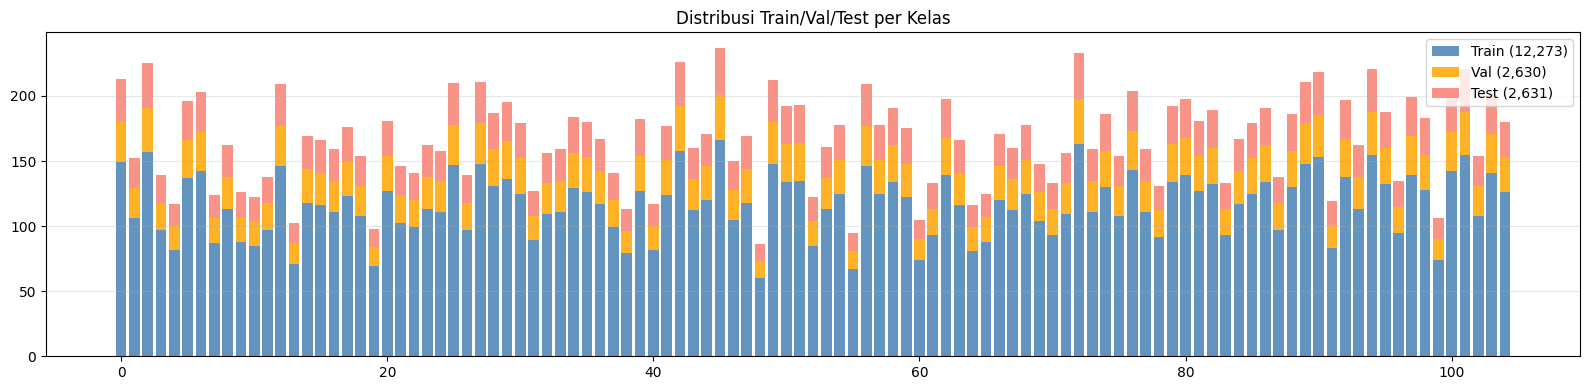

[13:42:20][INFO] Metadata split disimpan → /content/drive/MyDrive/Projek/face_recognition_ewallet/results/split_meta.json


Metadata split disimpan -> results/split.pkl


In [9]:
import pickle
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from collections import Counter

tr_set, val_set, te_set = set(Xtr), set(Xval), set(Xte)
assert len(tr_set & val_set) == 0, "LEAKAGE: train dan val overlap!"
assert len(tr_set & te_set)  == 0, "LEAKAGE: train dan test overlap!"
assert len(val_set & te_set) == 0, "LEAKAGE: val dan test overlap!"
print("Zero data leakage terkonfirmasi")

tr_counts  = [Counter(ytr).get(i, 0)  for i in range(num_classes)]
val_counts = [Counter(yval).get(i, 0) for i in range(num_classes)]
te_counts  = [Counter(yte).get(i, 0)  for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(16, 4))
x = range(num_classes)
ax.bar(x, tr_counts,  label=f'Train ({len(Xtr):,})',  color='steelblue', alpha=0.85)
ax.bar(x, val_counts, label=f'Val ({len(Xval):,})',   color='orange',    alpha=0.85,
       bottom=tr_counts)
ax.bar(x, te_counts,  label=f'Test ({len(Xte):,})',   color='salmon',    alpha=0.85,
       bottom=[t+v for t,v in zip(tr_counts, val_counts)])
ax.set_title('Distribusi Train/Val/Test per Kelas')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

loader.save_meta(train_d, val_d, test_d, cfg['paths']['results'])
meta = {'train': train_d, 'val': val_d, 'test': test_d,
        'class_to_idx': loader.class_to_idx,
        'idx_to_class': loader.idx_to_class,
        'num_classes': num_classes}
with open(f"{cfg['paths']['results']}/split.pkl", 'wb') as f:
    pickle.dump(meta, f)
print("Metadata split disimpan -> results/split.pkl")

# 6 — Visualisasi Augmentasi

In [10]:
from src.data.augmentation import get_train_transform, get_val_transform, denormalize
from PIL import Image
import random

In [11]:
train_tf = get_train_transform(cfg)
val_tf   = get_val_transform(cfg)

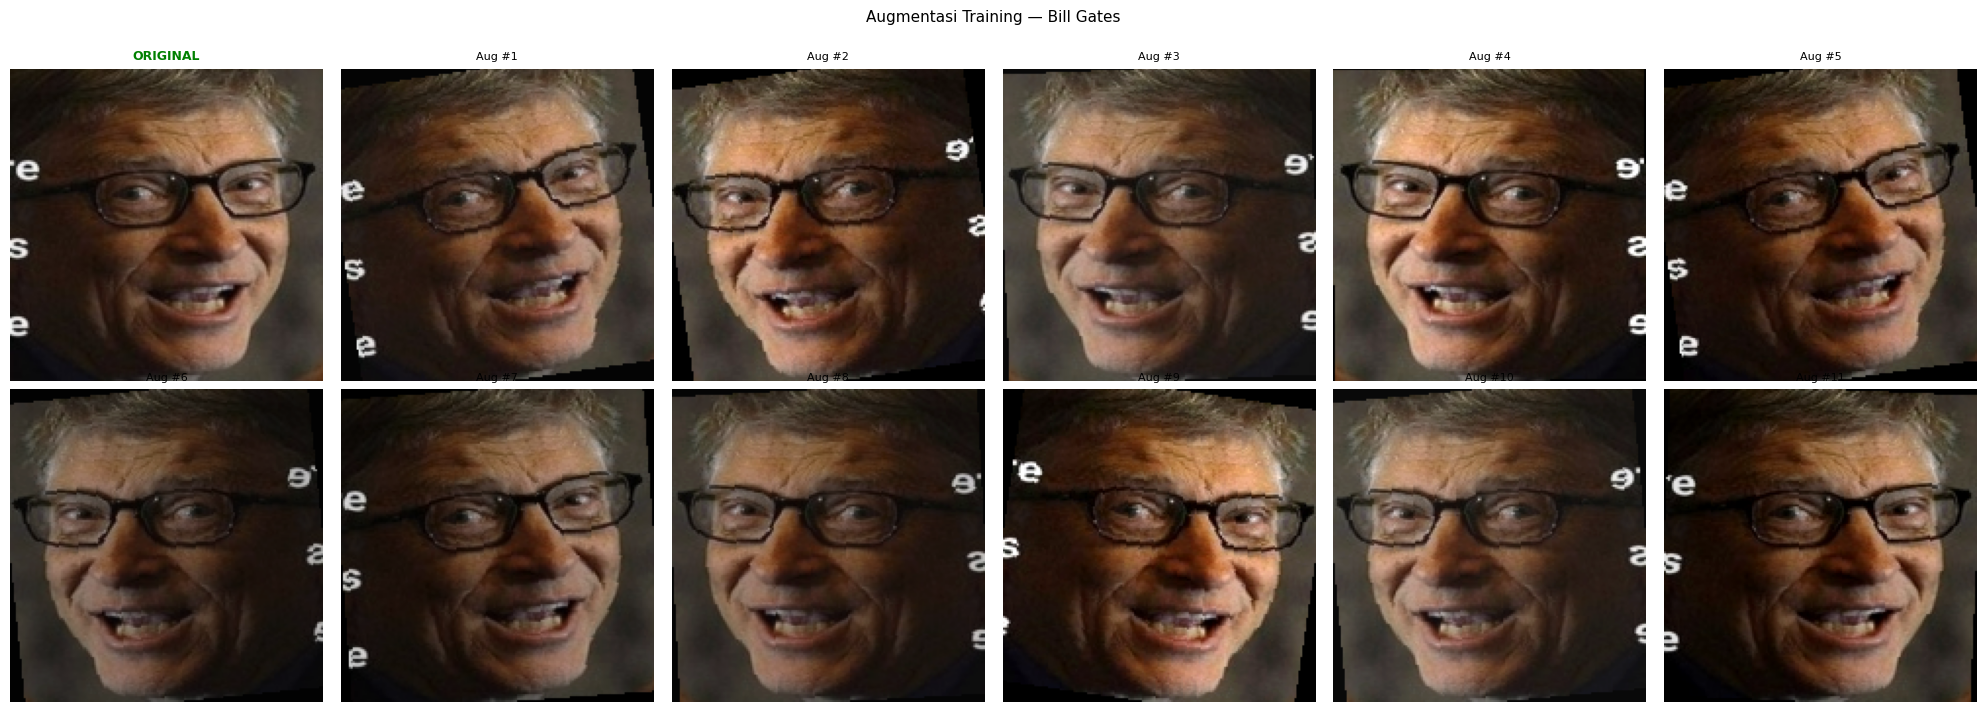

In [12]:
sample_path = random.choice(Xtr)
orig        = Image.open(sample_path).convert('RGB')

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
axes[0][0].imshow(orig.resize((160, 160)))
axes[0][0].set_title('ORIGINAL', color='green', fontweight='bold', fontsize=9)
axes[0][0].axis('off')

for i in range(11):
    row, col = (i+1) // 6, (i+1) % 6
    axes[row][col].imshow(denormalize(train_tf(orig)))
    axes[row][col].set_title(f'Aug #{i+1}', fontsize=8)
    axes[row][col].axis('off')

cls_name = sample_path.split('/')[-2]
plt.suptitle(f'Augmentasi Training — {cls_name}', fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

# 7 — DataLoader

In [13]:
train_loader, val_loader, test_loader = loader.make_loaders(
    train_d, val_d, test_d, train_tf, val_tf
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print(f"Batch size    : {cfg['training']['batch_size']}")

imgs_sample, lbl_sample = next(iter(train_loader))
print(f"\nSample batch shape : {imgs_sample.shape}")
print(f"Nilai min/max      : {imgs_sample.min():.2f} / {imgs_sample.max():.2f}")

[13:42:23][INFO] DataLoader siap — train:383 val:83 test:83 batch (bs=32)


Train batches : 383
Val batches   : 83
Test batches  : 83
Batch size    : 32

Sample batch shape : torch.Size([32, 3, 160, 160])
Nilai min/max      : -1.00 / 1.00


# 8 — Model Summary

In [14]:
from src.models.backbone import FaceRecognitionModel
import torch

model = FaceRecognitionModel(num_classes, cfg)

print(f"Backbone    : InceptionResnetV1 (VGGFace2 pretrained)")
print(f"Total param : {model.total_count():,}")
print(f"Trainable   : {model.trainable_count():,}  (head only, backbone belum di-unfreeze)")
print(f"Kelas output: {num_classes}")
print()
print(f"Phase 1 ({cfg['training']['phase1_epochs']} epoch) : backbone frozen, train head saja")
print(f"Phase 2 ({cfg['training']['phase2_epochs']} epoch) : full fine-tuning")
print(f"  Backbone LR : {cfg['training']['phase2_bb_lr']}")
print(f"  Head LR     : {cfg['training']['phase2_lr']}")

  0%|          | 0.00/107M [00:00<?, ?B/s]

[13:42:47][INFO] FaceRecognitionModel | backbone=InceptionResnetV1 pretrained=vggface2 | head→105 kelas


Backbone    : InceptionResnetV1 (VGGFace2 pretrained)
Total param : 27,965,216
Trainable   : 27,965,216  (head only, backbone belum di-unfreeze)
Kelas output: 105

Phase 1 (5 epoch) : backbone frozen, train head saja
Phase 2 (25 epoch) : full fine-tuning
  Backbone LR : 1e-05
  Head LR     : 0.0001


# 9 — Estimasi Waktu

In [15]:
import time

model_tmp   = model.to(device)
imgs_tmp, _ = next(iter(train_loader))
imgs_tmp    = imgs_tmp.to(device)

t0 = time.time()
with torch.no_grad():
    _ = model_tmp(imgs_tmp)
sec_per_batch = time.time() - t0

p1 = cfg['training']['phase1_epochs']
p2 = cfg['training']['phase2_epochs']
sec_per_ep = sec_per_batch * (len(train_loader) + len(val_loader))

print(f"Waktu per batch    : {sec_per_batch*1000:.0f} ms")
print(f"Estimasi per epoch : {sec_per_ep/60:.1f} menit")
print(f"Total epoch        : {p1+p2}")
print(f"Estimasi total     : {sec_per_ep*(p1+p2)/3600:.1f} jam")

del model_tmp, imgs_tmp
torch.cuda.empty_cache()

Waktu per batch    : 1161 ms
Estimasi per epoch : 9.0 menit
Total epoch        : 30
Estimasi total     : 4.5 jam


# 10 — Training

In [16]:
from src.models.backbone import FaceRecognitionModel
from src.training.trainer import Trainer
from pathlib import Path

In [17]:
RESUME = False   # <- ganti True jika ingin lanjut dari checkpoint

In [18]:
model = FaceRecognitionModel(num_classes, cfg).to(device)

[13:43:12][INFO] FaceRecognitionModel | backbone=InceptionResnetV1 pretrained=vggface2 | head→105 kelas


In [19]:
ckpt_path = Path(cfg['paths']['checkpoints']) / 'best_model.pt'
if RESUME and ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print(f"Resume dari epoch {ckpt['epoch']+1}, val_acc={ckpt['val_acc']:.4f}")

In [20]:
trainer = Trainer(model, train_loader, val_loader, cfg, device)

/content/drive/MyDrive/Projek/face_recognition_ewallet/src/training/trainer.py:71: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler  = GradScaler(enabled=self.amp)   # untuk mixed precision


In [21]:
print("="*55)
print("  TRAINING DIMULAI")
print(f"  Target: val_accuracy >= 90%")
print("="*55)

  TRAINING DIMULAI
  Target: val_accuracy >= 90%


In [22]:
history = trainer.train()

print(f"\nBest val_accuracy : {history.best_val_acc():.4f} ({history.best_val_acc()*100:.2f}%)")
print(f"Best epoch        : {history.best_epoch()}")
if history.best_val_acc() >= 0.90:
    print("TARGET >= 90% TERCAPAI!")
else:
    print("Belum capai 90%. Coba tambah phase2_epochs di config.yaml.")

[13:43:13][INFO] Backbone frozen (Phase 1: head-only training)
[13:43:13][INFO] Phase 1 optimizer: Adam lr=0.001 (head only)
[13:43:13][INFO] =======================================================
[13:43:13][INFO] PHASE 1 — CrossEntropy, backbone frozen [5 epoch]
[13:43:13][INFO] =======================================================
/content/drive/MyDrive/Projek/face_recognition_ewallet/src/training/trainer.py:119: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.amp):       # mixed precision forward pass
/content/drive/MyDrive/Projek/face_recognition_ewallet/src/training/trainer.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.amp):
[14:09:05][INFO] [P1 01/5] tr_loss=1.9705 tr_acc=0.7303 | va_loss=1.0574 va_acc=0.9897 | lr=9.05e-04 | 1552s
[14:09:12][INFO]   ✅ Best checkp


Best val_accuracy : 0.9966 (99.66%)
Best epoch        : 19
TARGET >= 90% TERCAPAI!


# 11 — Training Curves

In [23]:
import numpy as np

epochs = range(1, len(history.train_loss) + 1)
p1_end = next((i for i, p in enumerate(history.phase) if p == 'P2'), len(list(epochs)))

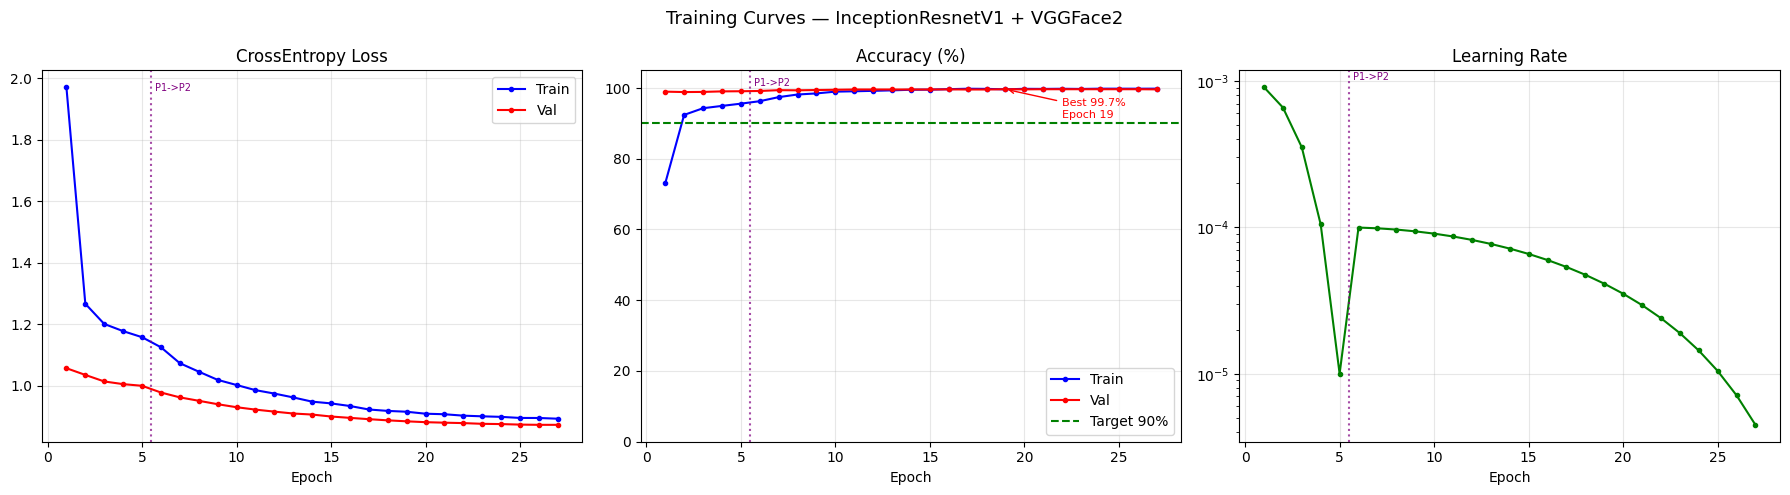

Lanjut ke Notebook 03 untuk evaluasi lengkap.


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history.train_loss, 'b-o', label='Train', markersize=3, linewidth=1.5)
axes[0].plot(epochs, history.val_loss,   'r-o', label='Val',   markersize=3, linewidth=1.5)
axes[0].set_title('CrossEntropy Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

tr_pct  = [a * 100 for a in history.train_acc]
val_pct = [a * 100 for a in history.val_acc]
axes[1].plot(epochs, tr_pct,  'b-o', label='Train', markersize=3, linewidth=1.5)
axes[1].plot(epochs, val_pct, 'r-o', label='Val',   markersize=3, linewidth=1.5)
axes[1].axhline(90, color='green', linestyle='--', linewidth=1.5, label='Target 90%')
best_ep  = history.best_epoch()
best_acc = history.best_val_acc() * 100
axes[1].annotate(f'Best {best_acc:.1f}%\nEpoch {best_ep}',
                 xy=(best_ep, best_acc),
                 xytext=(best_ep + max(1, len(list(epochs))//8), best_acc - 8),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 105); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history.lr, 'g-o', markersize=3, linewidth=1.5)
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

for ax in axes:
    if p1_end < len(list(epochs)):
        ax.axvline(p1_end + 0.5, color='purple', linestyle=':', alpha=0.7)
        ax.text(p1_end + 0.7, ax.get_ylim()[1] * 0.98,
                'P1->P2', fontsize=7, color='purple', va='top')

plt.suptitle('Training Curves — InceptionResnetV1 + VGGFace2', fontsize=13)
plt.tight_layout()
plt.savefig(f"{cfg['paths']['results']}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Lanjut ke Notebook 03 untuk evaluasi lengkap.")